In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM
import typing

In [ ]:
#achei interessante inserir o BTC_USD, já que o ciclo temporal basicamente troca de ATH em ATH
tickers: list[str] = ['AAPL', 'MSFT', 'GOOGL', 'BTC-USD', 'IBM']

#Visualização como no 5Y do Google
start_date: str = '2020-01-01'
end_date = None

window_size: int = 30


In [ ]:
def setup_tickers(tickers: list[str], start_date, end_date):
  series = []
  for ticker in tickers:
    df = yf.download(ticker, start_date, end_date)
    series.append(df[['Close']].dropna())
  return series

def test_tickers_data(dataframe):
  print(dataframe.head())
  print(dataframe.tail())

def create_windows(data, window_size):
  X, Y = [], []
  for i in range(len(data) - window_size):
    X.append(data[i:i+window_size])
    Y.append(data[i+window_size])

  return np.array(X), np.array(Y)

def normalize_data(data):
  scaler = MinMaxScaler(feature_range=(0,1))
  scaled_data = scaler.fit_transform(data)
  return scaled_data, scaler

def train_test(X, Y):
  split = int(0.8 * len(X))

  X_train, X_test = X[:split], X[split:]
  Y_train, Y_test = Y[:split], Y[split:]

  return X_train, X_test, Y_train, Y_test

In [ ]:
def build_model(window_size):
  model = Sequential()
  model.add(LSTM(50, activation='tanh', input_shape=(window_size, 1)))
  model.add(Dense(1))
  model.compile(optimizer='adam', loss='mse')
  return model

def train_evaluate (model, X_train, Y_Train, X_test, Y_test, scaler):
  early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True)

  history = model.fit(X_train, Y_train, batch_size=32, epochs=50,
                      validation_split=0.2, callbacks=[early_stop],verbose=1)

  Y_pred = model.predict(X_test)
  Y_test_inv = scaler.inverse_transform(Y_test)
  Y_pred_inv = scaler.inverse_transform(Y_pred)

  rmse = np.sqrt(mean_squared_error(Y_test_inv, Y_pred_inv))

  return model, Y_test_inv, Y_pred_inv, rmse

def tomorrow_pred(model, series_scaled, window_size, scaler):
  last_window = series_scaled[-window_size:]
  last_window = last_window.reshape(1, window_size, 1)

  next_day_pred = model.predict(last_window)
  next_day_pred = scaler.inverse_transform(next_day_pred)

  return next_day_pred[0][0]

In [ ]:
def plot_graph_closing(ticker: str, series, label):
  plt.figure()
  plt.plot(series)
  plt.title(f"{label} - {ticker}")
  plt.xlabel("Data")
  plt.ylabel("Preço de fechamento")
  plt.show()

def plot_graph_closing_prediction(ticker: str, series_original, y_test_inv, y_pred_inv):
  plt.figure()
  plt.plot(series_original.index[-len(y_test_inv):],
           y_test_inv, label="Valor Real")
  plt.plot(series_original.index[-len(y_pred_inv):],
           y_pred_inv,label="Valor previsto")
  plt.title(f"Comparativo de previsão e real da ação {ticker} utilizando LSTM")
  plt.xlabel("Data")
  plt.ylabel("Preço")
  plt.legend()
  plt.show()

In [ ]:

all_series = setup_tickers(tickers, start_date, end_date)

for serie in all_series:
  test_tickers_data(serie)




/tmp/ipython-input-523/3550828208.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-523/3550828208.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-523/3550828208.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-523/3550828208.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start_date, end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-523/3550828208.py:4: FutureWarning: Y

Price           Close
Ticker           AAPL
Date                 
2020-01-02  72.400520
2020-01-03  71.696632
2020-01-06  72.267952
2020-01-07  71.928047
2020-01-08  73.085098
Price            Close
Ticker            AAPL
Date                  
2026-02-23  266.179993
2026-02-24  272.140015
2026-02-25  274.230011
2026-02-26  272.950012
2026-02-27  264.179993
Price            Close
Ticker            MSFT
Date                  
2020-01-02  152.158386
2020-01-03  150.263763
2020-01-06  150.652145
2020-01-07  149.278534
2020-01-08  151.656281
Price            Close
Ticker            MSFT
Date                  
2026-02-23  384.470001
2026-02-24  389.000000
2026-02-25  400.600006
2026-02-26  401.720001
2026-02-27  392.739990
Price           Close
Ticker          GOOGL
Date                 
2020-01-02  67.920799
2020-01-03  67.565491
2020-01-06  69.366394
2020-01-07  69.232407
2020-01-08  69.725182
Price            Close
Ticker           GOOGL
Date                  
2026-02-23  311.489990
2026

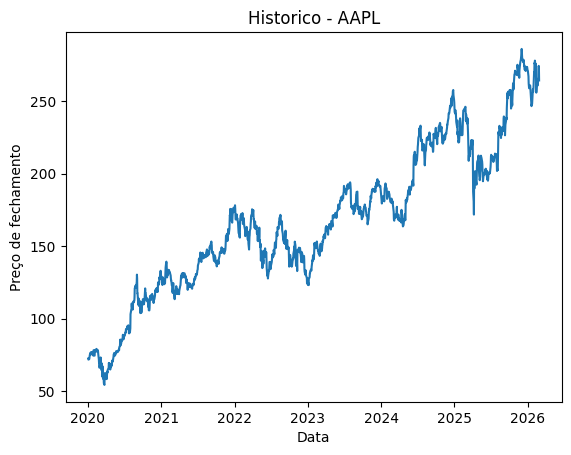

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0414 - val_loss: 0.0129
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - val_loss: 0.0026
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 8.6263e-04 - val_loss: 9.6336e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.5509e-04 - val_loss: 6.6234e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.0496e-04 - val_loss: 6.3594e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.1955e-04 - val_loss: 6.2334e-04
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.6734e-04 - val_loss: 6.0665e-04
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.7327e-04 - val_loss: 6.0839e-04
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.5350e-04 - val_loss: 6.0300e-04
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.3284e-04 - val_loss: 5.7067e-04
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.3481e-04 - val_loss: 5.5978e-04
Ep

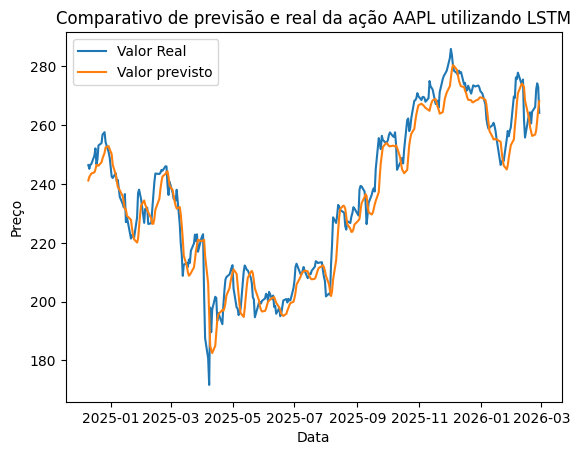

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Previsao proximo dia AAPL: 267.42


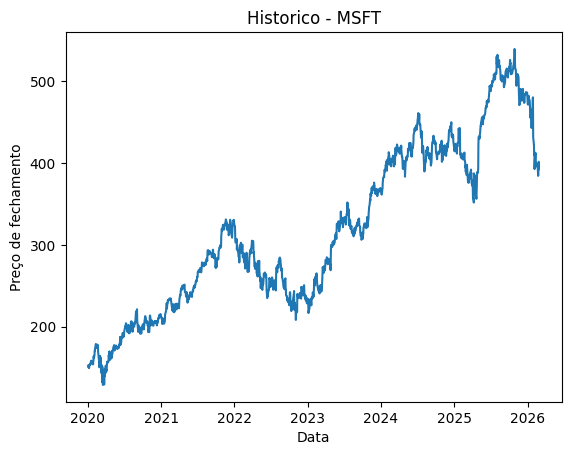

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0590 - val_loss: 0.0373
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0032 - val_loss: 0.0079
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 8.7651e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.4037e-04 - val_loss: 0.0013
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.1903e-04 - val_loss: 0.0012
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.0494e-04 - val_loss: 0.0016
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.3268e-04 - val_loss: 0.0012
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.9134e-04 - val_loss: 0.0015
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.7722e-04 - val_loss: 0.0019
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.9008e-04 - val_loss: 0.0018
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.1037e-04 - val_loss: 7.7064e-04
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━

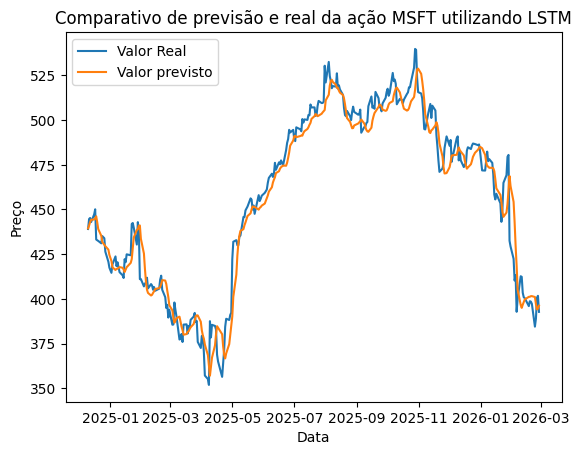

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Previsao proximo dia MSFT: 395.86


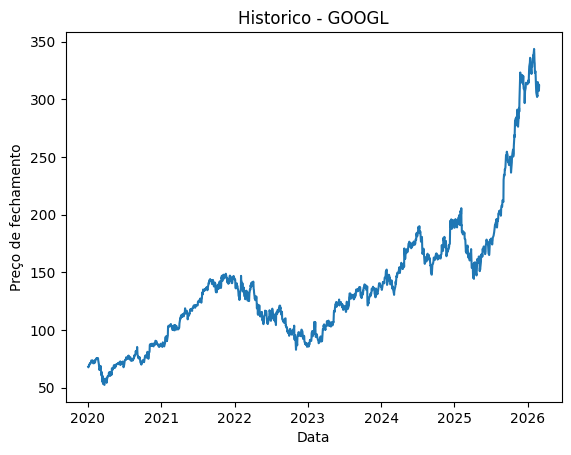

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0112 - val_loss: 0.0030
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.5158e-04 - val_loss: 5.1398e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.5302e-04 - val_loss: 4.1144e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.3485e-04 - val_loss: 4.0191e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.5105e-04 - val_loss: 3.8216e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.1643e-04 - val_loss: 3.7665e-04
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.2122e-04 - val_loss: 4.1982e-04
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.3682e-04 - val_loss: 3.8704e-04
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.0652e-04 - val_loss: 3.6892e-04
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 1.9625e-04 - val_loss: 3.2867e-04
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 2.0202e-04 - val_loss: 3.782

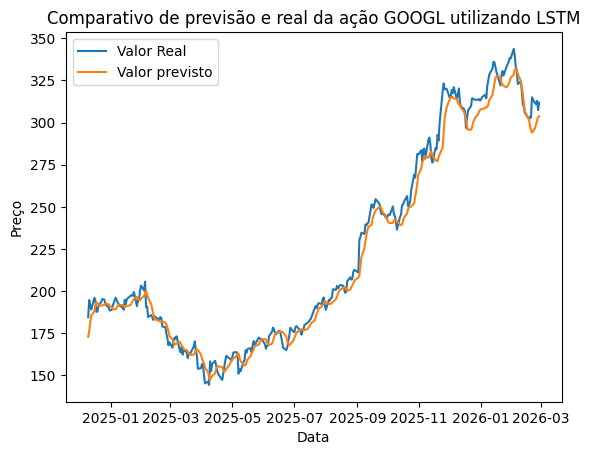

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Previsao proximo dia GOOGL: 304.78


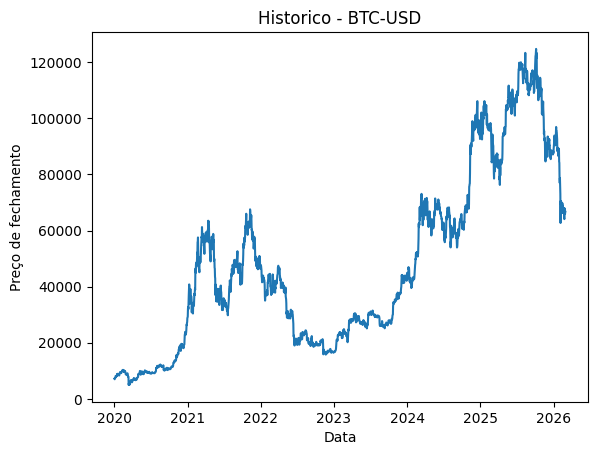

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0170 - val_loss: 0.0012
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6.5192e-04 - val_loss: 9.7042e-04
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.8744e-04 - val_loss: 8.6630e-04
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.8505e-04 - val_loss: 9.2298e-04
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.0799e-04 - val_loss: 8.1803e-04
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.6071e-04 - val_loss: 8.8829e-04
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 3.6648e-04 - val_loss: 6.7168e-04
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 3.1881e-04 - val_loss: 8.3427e-04
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 3.0792e-04 - val_loss: 6.8703e-04
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.8806e-04 - val_loss: 7.0564e-04
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.7267e-04 - val_loss: 5.622

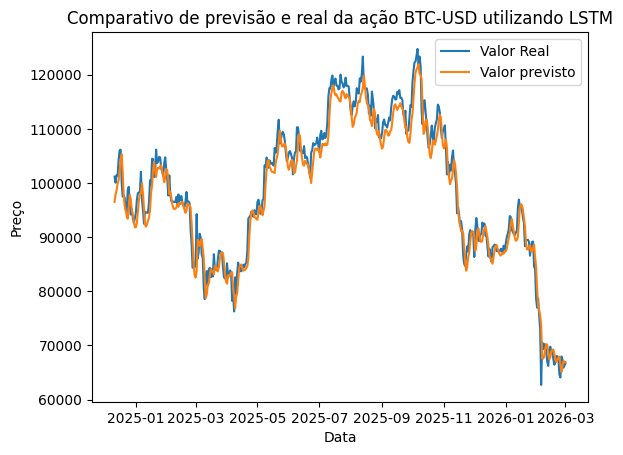

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Previsao proximo dia BTC-USD: 67035.08


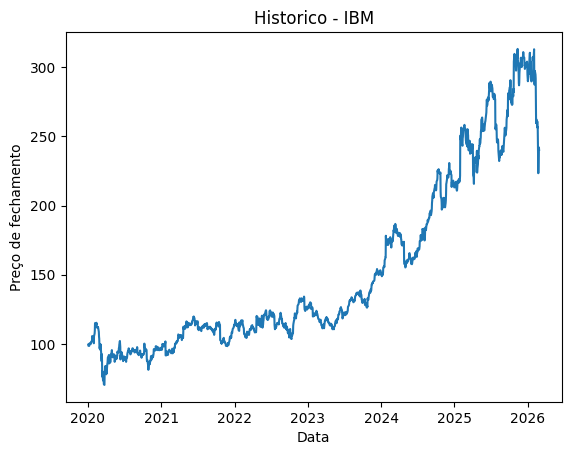

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0164 - val_loss: 0.0298
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0010 - val_loss: 0.0087
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4.7343e-04 - val_loss: 9.2669e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.9385e-04 - val_loss: 0.0012
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2.7229e-04 - val_loss: 0.0011
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 2.5487e-04 - val_loss: 0.0015
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 2.3765e-04 - val_loss: 0.0011
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.3933e-04 - val_loss: 9.1580e-04
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.3798e-04 - val_loss: 9.2759e-04
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.3863e-04 - val_loss: 0.0011
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.0949e-04 - val_loss: 8.8983e-04
Epoch 12/50
31/31 ━━━━

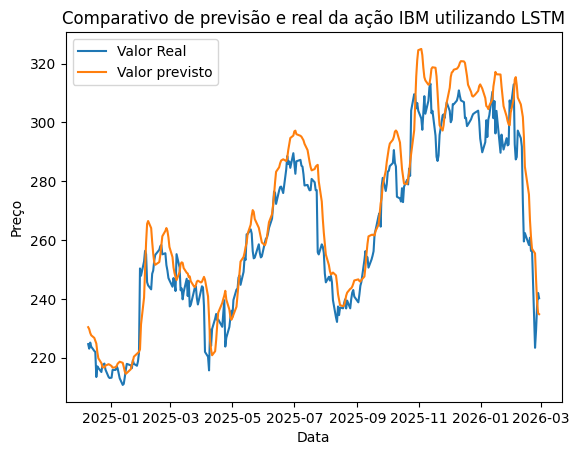

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Previsao proximo dia IBM: 236.26


In [ ]:
for i, serie in enumerate(all_series):
  ticker = tickers[i]

  plot_graph_closing(ticker, serie, "Historico")

  scaled_data, scaler = normalize_data(serie)
  X, Y = create_windows(scaled_data, window_size)
  X_train, X_test, Y_train, Y_test = train_test(X, Y)

  model = build_model(window_size)
  model, y_test_inv, y_pred_inv, rmse = train_evaluate(model, X_train, Y_train, X_test, Y_test, scaler)

  print(f"RMSE {ticker}: {rmse}")

  plot_graph_closing_prediction(ticker, serie, y_test_inv, y_pred_inv)

  next_price = tomorrow_pred(model, scaled_data, window_size, scaler)
  print(f"Previsao proximo dia {ticker}: {next_price:.2f}")
